In [1]:
import pandas as pd
import numpy as np


In [3]:
data = pd.read_csv("DST_BIL54.csv")

# Parse month strings to UTC timestamps at first of month.
data["time"] = pd.to_datetime(data["time"] + "-01", format="%Y-%m-%d", utc=True)

# Year with fractional month component.
data["year"] = data["time"].dt.year + (data["time"].dt.month - 1) / 12

# Convert to millions.
data["total"] = pd.to_numeric(data["total"], errors="coerce") / 1e6

# Drop all other columns
data = data[["time", "year", "total"]]

# Train/test split.
teststart = pd.Timestamp("2024-01-01", tz="UTC")
Dtrain = data[data["time"] < teststart]
Dtest = data[data["time"] >= teststart]

Dtrain.head()


,time,year,total
0,2018-01-01 00:00:00+00:00,2018.000000,2.930483
1,2018-02-01 00:00:00+00:00,2018.083333,2.934044
2,2018-03-01 00:00:00+00:00,2018.166667,2.941422
3,2018-04-01 00:00:00+00:00,2018.250000,2.951498
4,2018-05-01 00:00:00+00:00,2018.333333,2.963093


## 1.1. Plot Training Data vs Time (x)

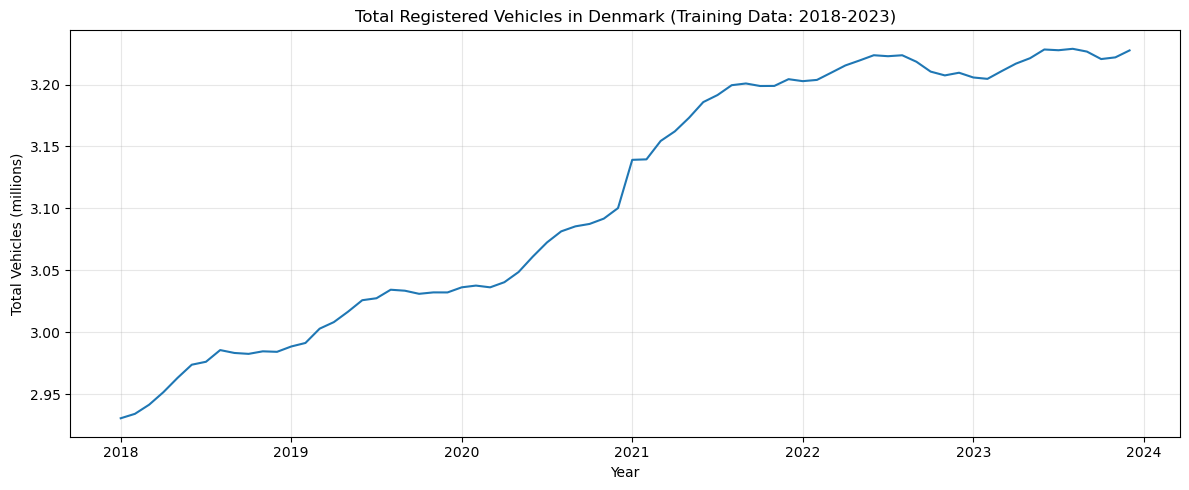

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(Dtrain["year"], Dtrain["total"], linewidth=1.5)
plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("Total Registered Vehicles in Denmark (Training Data: 2018-2023)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2. Time Series Description

**Observations:**

The time series shows the total number of registered vehicles in Denmark from 2018 to the end of 2023, measured in millions. Several key features are evident:

1. **Overall Trend**: There is a clear upward trend throughout the period, with the total number of vehicles increasing from approximately 2.93 million in early 2018 to about 3.23 million by the end of 2023.

2. **Growth Pattern**: The growth is not uniform:
   - **2018-2020**: Steady moderate growth with a relatively smooth trajectory
   - **2020-2021**: A period of accelerated growth with a noticeable increase in the rate of vehicle registrations
   - **2021-2022**: Sharp increase, particularly visible around mid-2021, where the series shows a steep upward movement
   - **2022-2023**: The growth rate slows down, and the series appears to level off somewhat, showing a slight plateau or oscillatory behavior around 3.2 million vehicles

3. **Potential Seasonality**: There appear to be some minor fluctuations or oscillations superimposed on the trend, which could indicate seasonal patterns in vehicle registrations.

4. **Recent Behavior**: In 2023, the series shows less pronounced growth compared to 2021-2022, with small ups and downs, suggesting potential market saturation or changes in registration patterns.

Overall, this is a non-stationary time series with a strong positive trend and possible seasonal components.

## 2. Linear Trend Model


### General Matrix Form

The linear trend model can be written as:

**y = Xθ + ϵ**

where:
- **y** is the N × 1 vector of observations
- **X** is the N × 2 design matrix
- **θ** is the 2 × 1 parameter vector
- **ϵ** is the N × 1 error vector with ϵ ∼ N(0, σ²I)

#### 1. Vector/Matrix Form:
```
⎡y₁⎤   ⎡1  x₁⎤ ⎡θ₁⎤   ⎡ϵ₁⎤
⎢y₂⎥ = ⎢1  x₂⎥ ⎢θ₂⎥ + ⎢ϵ₂⎥
⎣y₃⎦   ⎣1  x₃⎦ ⎣  ⎦   ⎣ϵ₃⎦
```

#### 2. With Element Notation:
```
⎡y₁⎤   ⎡1  x₁⎤ ⎡θ₁⎤   ⎡ϵ₁⎤
⎢y₂⎥ = ⎢1  x₂⎥ ⎢θ₂⎥ + ⎢ϵ₂⎥
⎣y₃⎦   ⎣1  x₃⎦ ⎣  ⎦   ⎣ϵ₃⎦

where:
- y₁, y₂, y₃ are the observed total vehicles (in millions)
- x₁, x₂, x₃ are the time values
- θ₁ is the intercept
- θ₂ is the slope (trend coefficient)
- ϵ₁, ϵ₂, ϵ₃ are the error terms
```

In [25]:
print("First 3 observations:")
print(Dtrain[["year", "total"]].head(3))
print("\nActual values (rounded to 3 digits):")
print(f"x₁ = {Dtrain['year'].iloc[0]:.3f}, y₁ = {Dtrain['total'].iloc[0]:.3f}")
print(f"x₂ = {Dtrain['year'].iloc[1]:.3f}, y₂ = {Dtrain['total'].iloc[1]:.3f}")
print(f"x₃ = {Dtrain['year'].iloc[2]:.3f}, y₃ = {Dtrain['total'].iloc[2]:.3f}")

First 3 observations:
          year     total
0  2018.000000  2.930483
1  2018.083333  2.934044
2  2018.166667  2.941422

Actual values (rounded to 3 digits):
x₁ = 2018.000, y₁ = 2.930
x₂ = 2018.083, y₂ = 2.934
x₃ = 2018.167, y₃ = 2.941


```
⎡2.933⎤   ⎡1  2018.000⎤ ⎡θ₁⎤   ⎡ϵ₁⎤
⎢2.938⎥ = ⎢1  2018.083⎥ ⎢θ₂⎥ + ⎢ϵ₂⎥
⎣2.943⎦   ⎣1  2018.167⎦ ⎣  ⎦   ⎣ϵ₃⎦
```

## 3. OLS - Global Linear Trend Model

In [26]:
## 3.1. OLS Parameter Estimation

# Construct the design matrix X and output vector y
X = np.column_stack([np.ones(len(Dtrain)), Dtrain["year"]])
y = Dtrain["total"].values

# OLS estimate: θ̂ = (X'X)^(-1) X'y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("OLS Parameter Estimates:")
print(f"θ̂₁ (intercept) = {theta_hat[0]:.6f}")
print(f"θ̂₂ (slope)     = {theta_hat[1]:.6f}")

# Interpretation
print("\n" + "="*60)
print("Interpretation:")
print("="*60)
print(f"Intercept (θ̂₁): {theta_hat[0]:.3f} million vehicles")
print(f"Trend (θ̂₂):     {theta_hat[1]:.6f} million vehicles per year")
print(f"\nThe model estimates that vehicle registrations increase by")
print(f"approximately {theta_hat[1]*1000:.1f} thousand vehicles per year.")

OLS Parameter Estimates:
θ̂₁ (intercept) = -110.355428
θ̂₂ (slope)     = 0.056145

Interpretation:
Intercept (θ̂₁): -110.355 million vehicles
Trend (θ̂₂):     0.056145 million vehicles per year

The model estimates that vehicle registrations increase by
approximately 56.1 thousand vehicles per year.


In [27]:
## 3.2. Parameter Estimates with Standard Errors

# Calculate residuals
y_hat = X @ theta_hat
residuals = y - y_hat

# Estimate residual variance: σ̂² = (1/(N-p)) * Σeᵢ²
N = len(y)
p = 2  # number of parameters
sigma_squared_hat = np.sum(residuals**2) / (N - p)

# Covariance matrix of parameter estimates: Var(θ̂) = σ̂² * (X'X)⁻¹
cov_theta = sigma_squared_hat * np.linalg.inv(X.T @ X)

# Standard errors are square roots of diagonal elements
se_theta = np.sqrt(np.diag(cov_theta))

# Display results
print("="*70)
print("OLS PARAMETER ESTIMATES WITH STANDARD ERRORS")
print("="*70)
print(f"θ̂₁ (intercept) = {theta_hat[0]:12.6f}  ±  {se_theta[0]:.6f}")
print(f"θ̂₂ (slope)     = {theta_hat[1]:12.6f}  ±  {se_theta[1]:.6f}")
print(f"\nResidual standard deviation (σ̂) = {np.sqrt(sigma_squared_hat):.6f} million vehicles")
print(f"Degrees of freedom = {N - p}")
print("="*70)

# Calculate t-statistics and p-values (optional but informative)
t_stats = theta_hat / se_theta
from scipy import stats
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), N - p))

print("\nStatistical Significance:")
print(f"t-statistic for θ₁: {t_stats[0]:.3f}, p-value: {p_values[0]:.6f}")
print(f"t-statistic for θ₂: {t_stats[1]:.3f}, p-value: {p_values[1]:.6f}")

OLS PARAMETER ESTIMATES WITH STANDARD ERRORS
θ̂₁ (intercept) =  -110.355428  ±  3.593581
θ̂₂ (slope)     =     0.056145  ±  0.001778

Residual standard deviation (σ̂) = 0.026131 million vehicles
Degrees of freedom = 70

Statistical Significance:
t-statistic for θ₁: -30.709, p-value: 0.000000
t-statistic for θ₂: 31.575, p-value: 0.000000


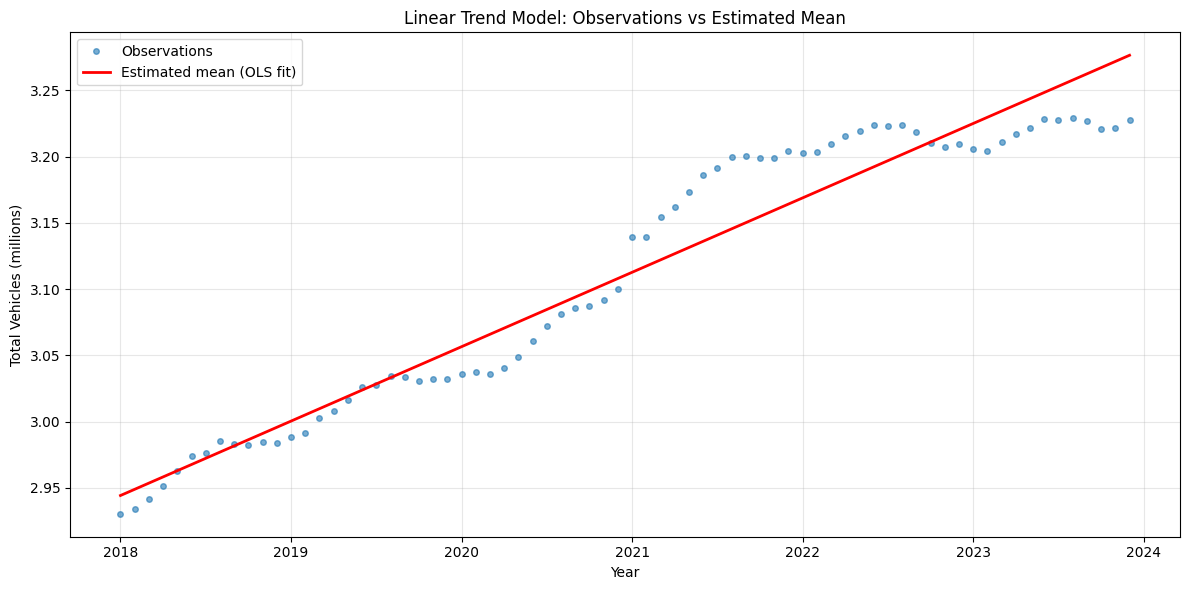


Estimated Model:
ŷ = -110.355428 + 0.056145 × year


In [ ]:
## 3.2. Plot: Observations and Estimated Mean

plt.figure(figsize=(12, 6))

# Plot observations as points
plt.plot(Dtrain["year"], Dtrain["total"], 'o', 
         markersize=4, alpha=0.6, label='Observations')

# Plot estimated mean as a line
plt.plot(Dtrain["year"], y_hat, '-', 
         linewidth=2, color='red', label='Estimated mean (OLS fit)')

plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("Linear Trend Model: Observations vs Estimated Mean")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print model equation
print(f"\nEstimated Model:")
print(f"ŷ = {theta_hat[0]:.6f} + {theta_hat[1]:.6f} × year")